In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import warnings
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score,classification_report

In [2]:
pd.set_option("display.max_columns",None)
pd.set_option("display.width",600)
pd.set_option("display.max_rows",600)
pd.set_option("display.float_format",lambda x:"%.2f" %x)
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("C:\\Users\\Ali Can\\Desktop\\Proje\\DinamikProje\\data\\processed\\processed_data.csv")
df

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type,Day,Temperature Difference,Power [W],RPM_Torque_Ratio,Air_Process_Interaction,Temperature_Wear_Interaction,ToolWear_roll_mean_1_hours,ToolWear_roll_mean_6_hours,ToolWear_roll_mean_12_hours,ToolWear_roll_mean_24_hours,Type_H,Type_L,Type_M,Weekday_Friday,Weekday_Monday,Weekday_Saturday,Weekday_Sunday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday,Month_1,Month_2,Month_3,Month_4,Wear Category_Very Low,Wear Category_Low,Wear Category_Medium,Wear Category_High,Wear Category_Very High
0,-0.56,-0.75,1.49,-1.09,-0.91,No Failure,-1.46,0.00,-0.82,1.09,-0.66,-0.92,-1.07,-1.03,0.26,-1.91,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0
1,-0.56,-0.82,0.01,-0.80,-0.87,No Failure,-1.46,-0.10,-1.06,0.35,-0.69,-0.87,-1.03,-1.17,0.19,-1.85,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0
2,-0.61,-0.82,-0.03,0.43,-0.83,No Failure,-1.46,0.00,0.75,-0.44,-0.72,-0.84,-0.98,-1.30,0.13,-1.80,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0
3,-0.61,-0.75,2.17,-1.61,-0.80,No Failure,-1.46,0.10,-1.44,2.08,-0.69,-0.81,-0.94,-1.44,0.06,-1.74,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0
4,-0.61,-0.82,3.10,-2.06,-0.77,No Failure,-1.46,0.00,-1.96,3.48,-0.72,-0.78,-0.89,-1.58,-0.01,-1.68,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9728,-0.61,-1.08,0.51,-1.14,-1.48,No Failure,-0.08,-0.40,-1.33,0.83,-0.83,-1.48,-1.64,0.75,1.07,0.06,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0
9729,-0.56,-1.08,0.70,-0.89,-1.43,No Failure,-0.08,-0.50,-0.86,0.64,-0.80,-1.43,-1.60,0.61,1.00,-0.13,1,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0
9730,-0.51,-0.95,0.79,-0.73,-1.35,No Failure,-0.08,-0.40,-0.55,0.51,-0.71,-1.36,-1.56,0.47,0.93,-0.32,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0
9731,-0.51,-0.88,-0.80,0.86,-1.31,No Failure,-0.08,-0.30,0.82,-0.78,-0.69,-1.31,-1.51,0.33,0.86,-0.50,1,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0


In [4]:
len(df[df["Failure Type"] != "No Failure"])

304

In [5]:
len(df[df["Failure Type"] == "No Failure"])

9429

In [6]:
no_fail = df[df["Failure Type"] == "No Failure"]

In [7]:
silinecekler = no_fail.sample(n=8500,random_state=25).index
silinecekler

Int64Index([6106, 3682,  685, 1676, 1575, 3351, 3555, 6079, 4099, 1518,
            ...
            4539, 7049, 5194, 4726, 5271, 2267, 4992, 8150, 6918, 2458], dtype='int64', length=8500)

In [8]:
df.drop(list(silinecekler),inplace=True)

In [9]:
X = df.drop(["Failure Type"],axis=1)
y = df["Failure Type"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=96)

In [10]:
smoting = SMOTE()
X_smote_train,y_smote_train = smoting.fit_resample(X_train,y_train)

In [11]:
y_train.value_counts()

No Failure                  645
Heat Dissipation Failure     78
Overstrain Failure           51
Power Failure                45
Tool Wear Failure            28
Random Failures              16
Name: Failure Type, dtype: int64

In [12]:
y_smote_train.value_counts()

No Failure                  645
Tool Wear Failure           645
Heat Dissipation Failure    645
Random Failures             645
Power Failure               645
Overstrain Failure          645
Name: Failure Type, dtype: int64

In [13]:
model = RandomForestClassifier(n_estimators=500,random_state=96)
model.fit(X_smote_train,y_smote_train)
y_pred = model.predict(X_test)
accuracy_score(y_test,y_pred)

0.9459459459459459

In [14]:
print(classification_report(y_test,y_pred,zero_division=1))

                          precision    recall  f1-score   support

Heat Dissipation Failure       0.97      1.00      0.99        34
              No Failure       0.99      0.95      0.97       284
      Overstrain Failure       0.91      0.91      0.91        23
           Power Failure       1.00      1.00      1.00        15
         Random Failures       0.00      0.00      0.00         2
       Tool Wear Failure       0.48      0.83      0.61        12

                accuracy                           0.95       370
               macro avg       0.72      0.78      0.75       370
            weighted avg       0.96      0.95      0.95       370



In [15]:
def katsayilari_ciz(model, ozellikler, num=None, kaydet=False):
    if num is None:
        num = len(ozellikler.columns)
    
    ozellik_importances = model.feature_importances_
    ozellik_isimleri = ozellikler.columns
    
    ozellik_imp = pd.DataFrame({"Deger": ozellik_importances, "Ozellik": ozellik_isimleri})
    
    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Deger", y="Ozellik", data=ozellik_imp.sort_values(by="Deger", ascending=False)[:num])
    plt.title("Özellik Önem Dereceleri")
    plt.tight_layout()
    plt.show(block=True)
    
    if kaydet:
        plt.savefig("ozellik_onem_dereceleri.png")


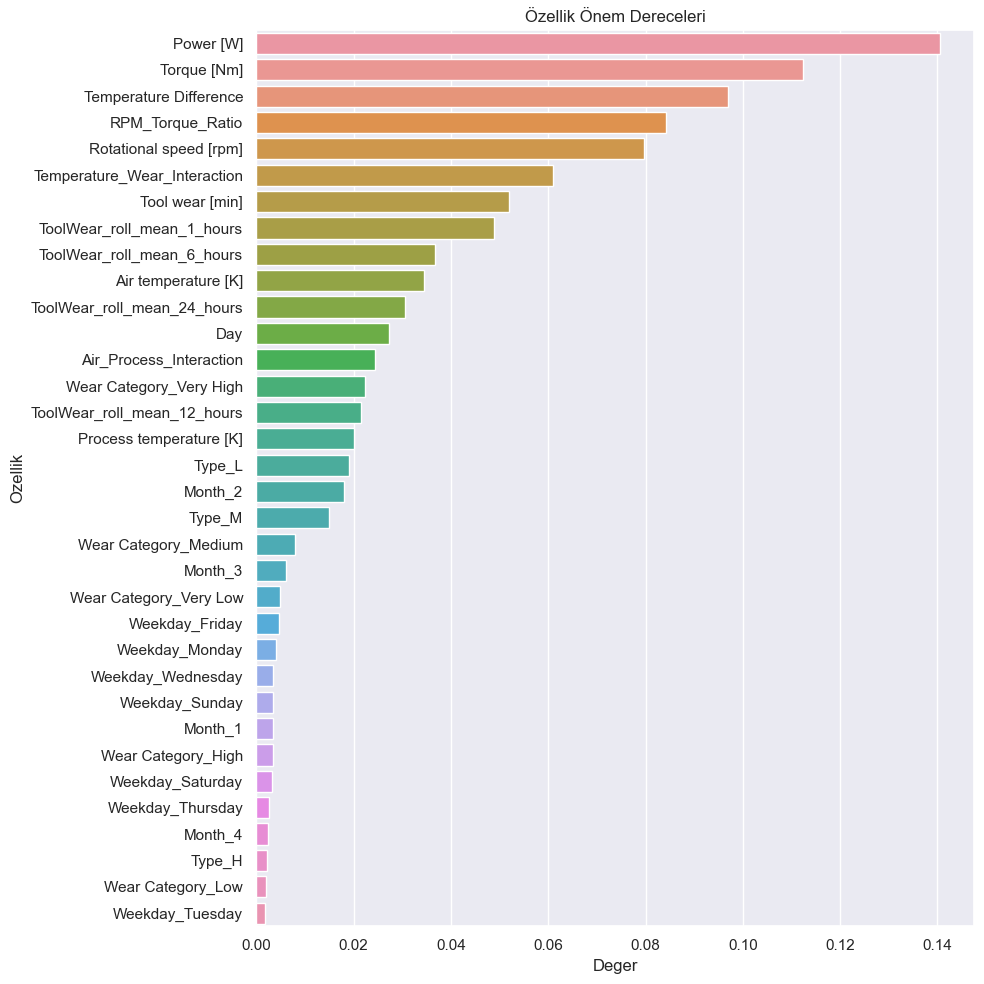

In [16]:
katsayilari_ciz(model,X)

In [17]:
joblib.dump(model,"C:\\Users\\Ali Can\\Desktop\\Proje\\DinamikProje\\models\\RandomForestModel_1.joblib")

['C:\\Users\\Ali Can\\Desktop\\Proje\\DinamikProje\\models\\RandomForestModel_1.joblib']